<a href="https://colab.research.google.com/github/joao2000/Trabalhos/blob/main/Potencial_e_Campo_via_Laplace_F%C3%ADsica_3_Trab_computacional2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Física Geral 3 - LE404A:

#Trabalho Computacional 2 - Solução do potencial e campo via Laplace
*Prof. Marcelo Zóega Maialle*

Alunos:

*João Augusto Dantas Camelo dos Santos - RA:237417*

Lucas Kenzo Yuhara - RA:240022

Miguel Cataldo Mendonça Leite - RA:185577

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import math

**1)Definindo parametros:**

In [ ]:
#RAS:
RA1 = 237417
RA2 = 240022
RA3 = 185577

Med = (RA1+RA2+RA3)/3
print("Média RA =",Med)
media = str(Med)
print("Média RA =",media)

m1 = media[5]
m2 = media[4]

print("Valor da unidade:",m1)
print("Valor da dezena:",m2)
#Média das unidades:
M1 = int(m1)
print("M1 =",M1)
#Média das dezenas:
print("Como o valor da dezanas é zero:")
M2 = 2
print("M2 =",M2)
#Largura:
La = 1
print("Largura: La =",La)

Média RA = 221005.33333333334
Média RA = 221005.33333333334
Valor da unidade: 5
Valor da dezena: 0
M1 = 5
Como o valor da dezanas é zero:
M2 = 2
Largura: La = 1


**2)Definindo condições de contorno, grade e chute inicial dos outros valores:**

(100, 100)
(100, 100)


<ipython-input-3-bdec45cff185>:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(Y, X, Z,cmap='magma',alpha=0.2)


Text(0.5, 0, 'Z')

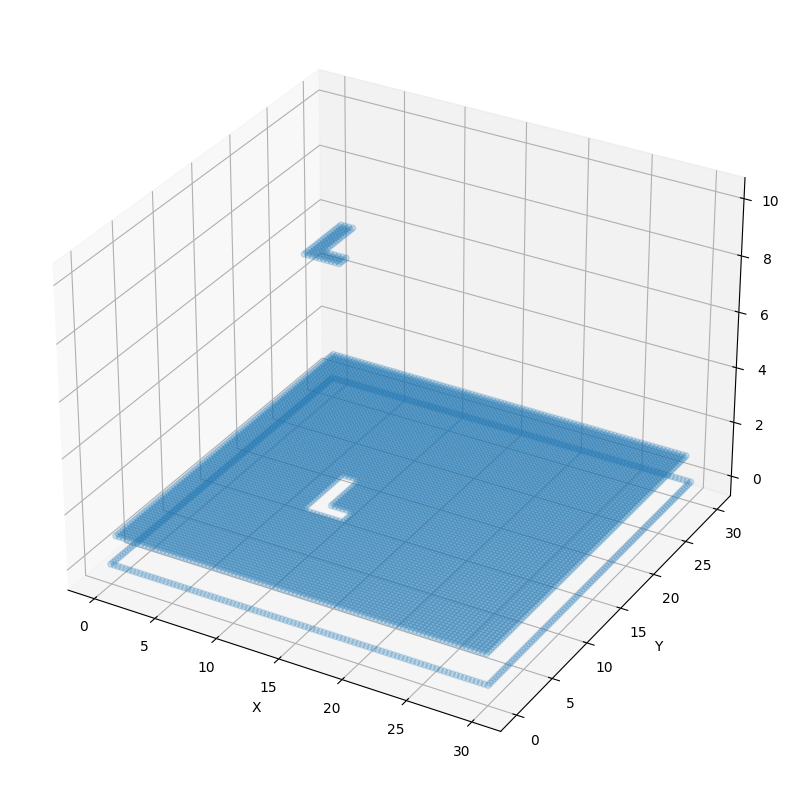

In [ ]:
#Def valores pros eixos x e y:

Nv = 100
x = np.linspace(0,30,Nv)
y = np.linspace(0,30,Nv)

#Grade relação de todos os posiveis valores de x e y:
X,Y = np.meshgrid(x,y)

#Vetor Z que vai receber os valores do potencial:
Z = np.ones((Nv,Nv))
print(Z.shape)
print(X.shape)

#Valores de contorno:
xi=0
for i in x:
  yi=0
  for j in y:
    #Valores em M1:
    if i>=10 and i<=10+La:
      if j>=10 and j<=10+M1:
        Z[xi][yi] = 10
    #Valores em M2:
    if i>=10+La and i<=10+La+M2:
      if j>=10 and j<=10+La:
        Z[xi][yi] = 10
        #print(Z[i][j])
    #Valores da borda:
    if i==0 or i==30 or j==0 or j==30:
      Z[xi][yi] = 0
    yi = yi+1
  xi = xi+1


fig=plt.figure()
fig.set_size_inches(10, 10)
ax = plt.axes(projection = '3d')
ax.scatter3D(Y, X, Z,cmap='magma',alpha=0.2)
#ax.scatter3D(10, 10, 0,cmap='g',alpha=1)


# ax.set_title("Ptencial Elétrico no R2")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
#ax.view_init(15, 40)


**3)Método iterativo e plotagem dos resultados:**

(100, 100)
(100, 100)


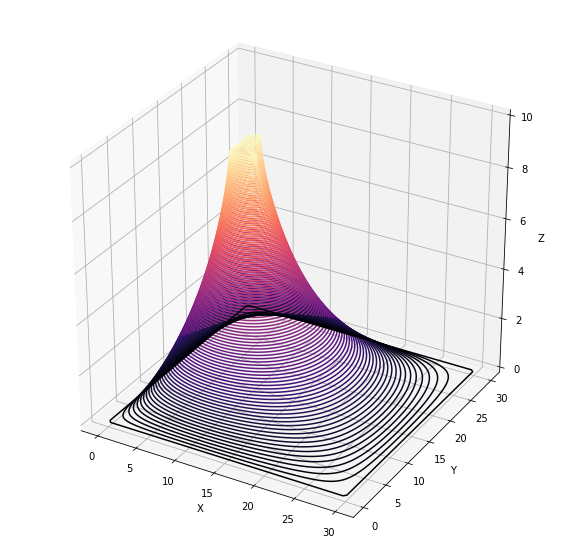

In [ ]:
#Def valores pros eixos x e y:

Nv = 100
x = np.linspace(0,30,Nv)
y = np.linspace(0,30,Nv)

#Grade relação de todos os posiveis valores de x e y:
X,Y = np.meshgrid(x,y)

#Vetor Z que vai receber os valores do potencial:
Z = np.ones((Nv,Nv))
print(Z.shape)
print(X.shape)

#Valores de contorno:
xi=0
for i in x:
  yi=0
  for j in y:
    #Valores em M1:
    if i>=10 and i<=10+La:
      if j>=10 and j<=10+M1:
        Z[xi][yi] = 10
    #Valores em M2:
    if i>=10+La and i<=10+La+M2:
      if j>=10 and j<=10+La:
        Z[xi][yi] = 10
        #print(Z[i][j])
    #Valores da borda:
    if i==0 or i==30 or j==0 or j==30:
      Z[xi][yi] = 0
    yi = yi+1
  xi = xi+1

#Iteração para os i j dentro, já indo usando os valores novos:
erro = 100
#Precisão
sig = 0.1
while erro>sig:
  #Zerar o erro para calcula-lo de novo
  erro = 0
  xi = 0
  for i in x:
    yi=0
    for j in y:
      #Certificar que não é de contorno com um ou exclusivo:
      if Z[xi][yi] != 10 and Z[xi][yi] != 0:
        # print("xi=",xi)
        # print("yi=",yi)
        # print(Z[xi][yi])
        #Novo valor, média dos quatro valores adjacetes:
        novo = 0.25*(Z[xi-1][yi]+Z[xi+1][yi]+Z[xi][yi-1]+Z[xi][yi+1])
        erro = erro + abs(novo-Z[xi][yi])/abs(novo)
        #Atualizar:
        Z[xi][yi] = novo
      yi = yi+1
    xi = xi+1

fig=plt.figure()
fig.set_size_inches(10, 10)
ax = plt.axes(projection = '3d')
#ax.scatter3D(X, Y, Z,cmap='magma',alpha=0.4)
ax.contour3D(Y,X,Z,100,cmap='magma')

# #Plotagem:
# fig=plt.figure()
# fig.set_size_inches(10, 10)
# ax = plt.axes(projection = '3d')
# ax.contour3D(X,Y,Z,500,cmap='magma')
# ax.scatter3D(X, Y, Z, s=(X/100), c=color, cmap='hot', alpha=0.4)

#ax.plot_surface(Y, X, Z, cmap = 'magma')

# ax.set_title("Ptencial Elétrico no R2")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
#ax.view_init(15, 40)

plt.show()


**4)Plotagem da superfície de contorno:**

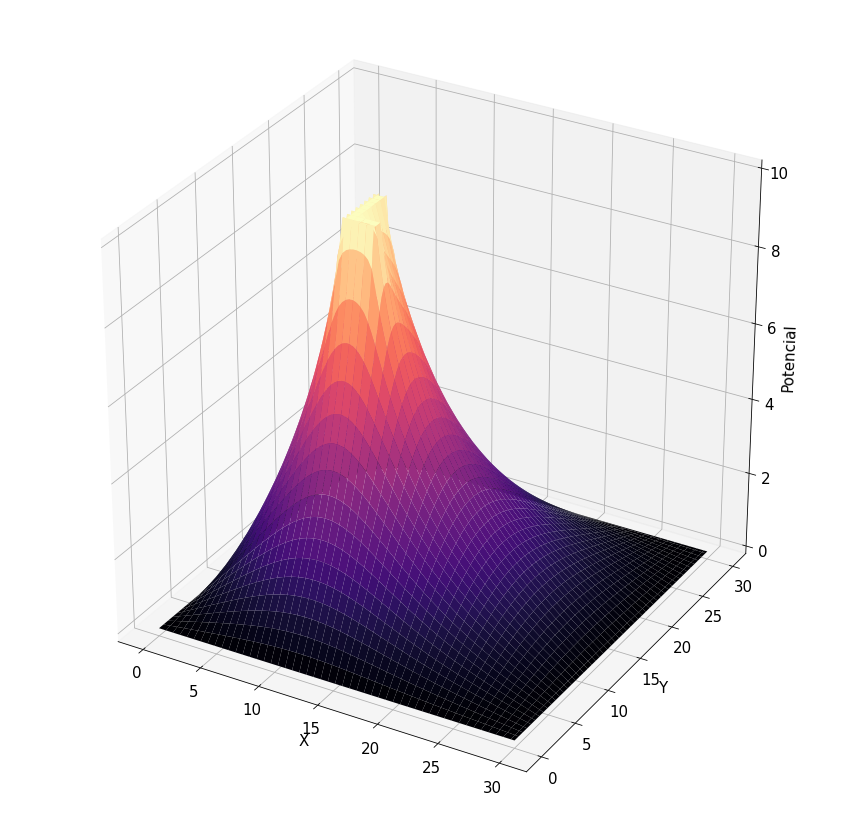

In [ ]:

fig=plt.figure()
fig.set_size_inches(15, 15)
ax = plt.axes(projection = '3d')
#ax.scatter3D(X, Y, Z,cmap='magma',alpha=0.4)
#ax.contour3D(X,Y,Z,150,cmap='magma')

#ax.scatter3D(Y, X, Z, c=Z, cmap='magma',alpha=0.6)

#ax.plot_surface(Y, X, Z,  cmap='autumn') #magma cool hot
#ax.plot_surface(Y, X, Z)
ax.plot_surface(Y, X, Z, cmap = 'magma')

ax.set_xlabel('X',fontsize=15)
ax.set_ylabel('Y',fontsize=15)
ax.set_zlabel('Potencial',fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

font = {'size': 15}
ax.tick_params('z', labelsize=font['size'])

#ax.view_init(90, 0)

plt.show()

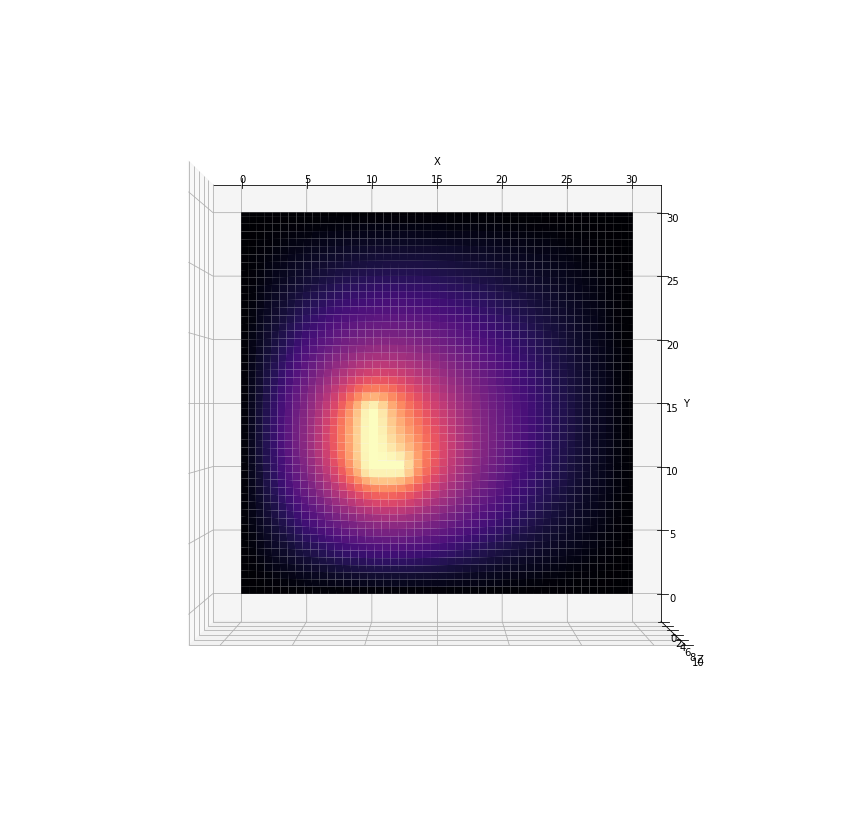

In [ ]:
fig=plt.figure()
fig.set_size_inches(15, 15)
ax = plt.axes(projection = '3d')
#ax.scatter3D(X, Y, Z,cmap='magma',alpha=0.4)
#ax.contour3D(X,Y,Z,150,cmap='magma')

#ax.scatter3D(Y, X, Z, c=Z, cmap='magma',alpha=0.6)

#ax.plot_surface(Y, X, Z,  cmap='autumn') #magma cool hot
#ax.plot_surface(Y, X, Z)
ax.plot_surface(Y, X, Z, cmap = 'magma')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(90,-90)

plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: UserWarning: The following kwargs were not used by contour: 'linewidth'
  This is separate from the ipykernel package so we can avoid doing imports until


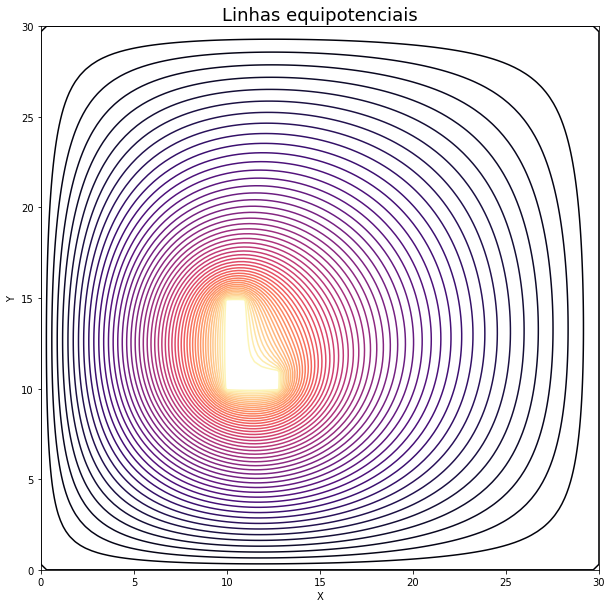

In [ ]:
# Plotando o gráfico das linhas potenciais
fig,ax=plt.subplots(figsize=(10,10))#'coolwarm'
ax.contour(Y, X, Z,50,cmap='magma', linewidth=0) # Plotar as linhas
plt.title("Linhas equipotenciais",fontsize=18)
plt.xlabel('X',fontsize=10)
plt.ylabel('Y',fontsize=10)
plt.show()

**5)Calculo e plotagem do campo elétrico:**

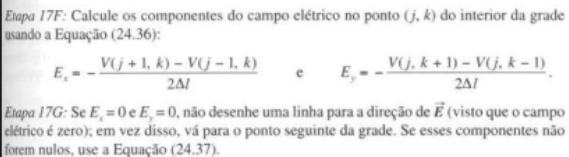

-0.17811745770854956
Ex(50,10) =  0.11991473851236227
Ex(10,30) -0.6453210201166518
0.10794997436881792
0.28992161868563204
-1.3816332438529209


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:70: UserWarning: The following kwargs were not used by contour: 'linewidth'


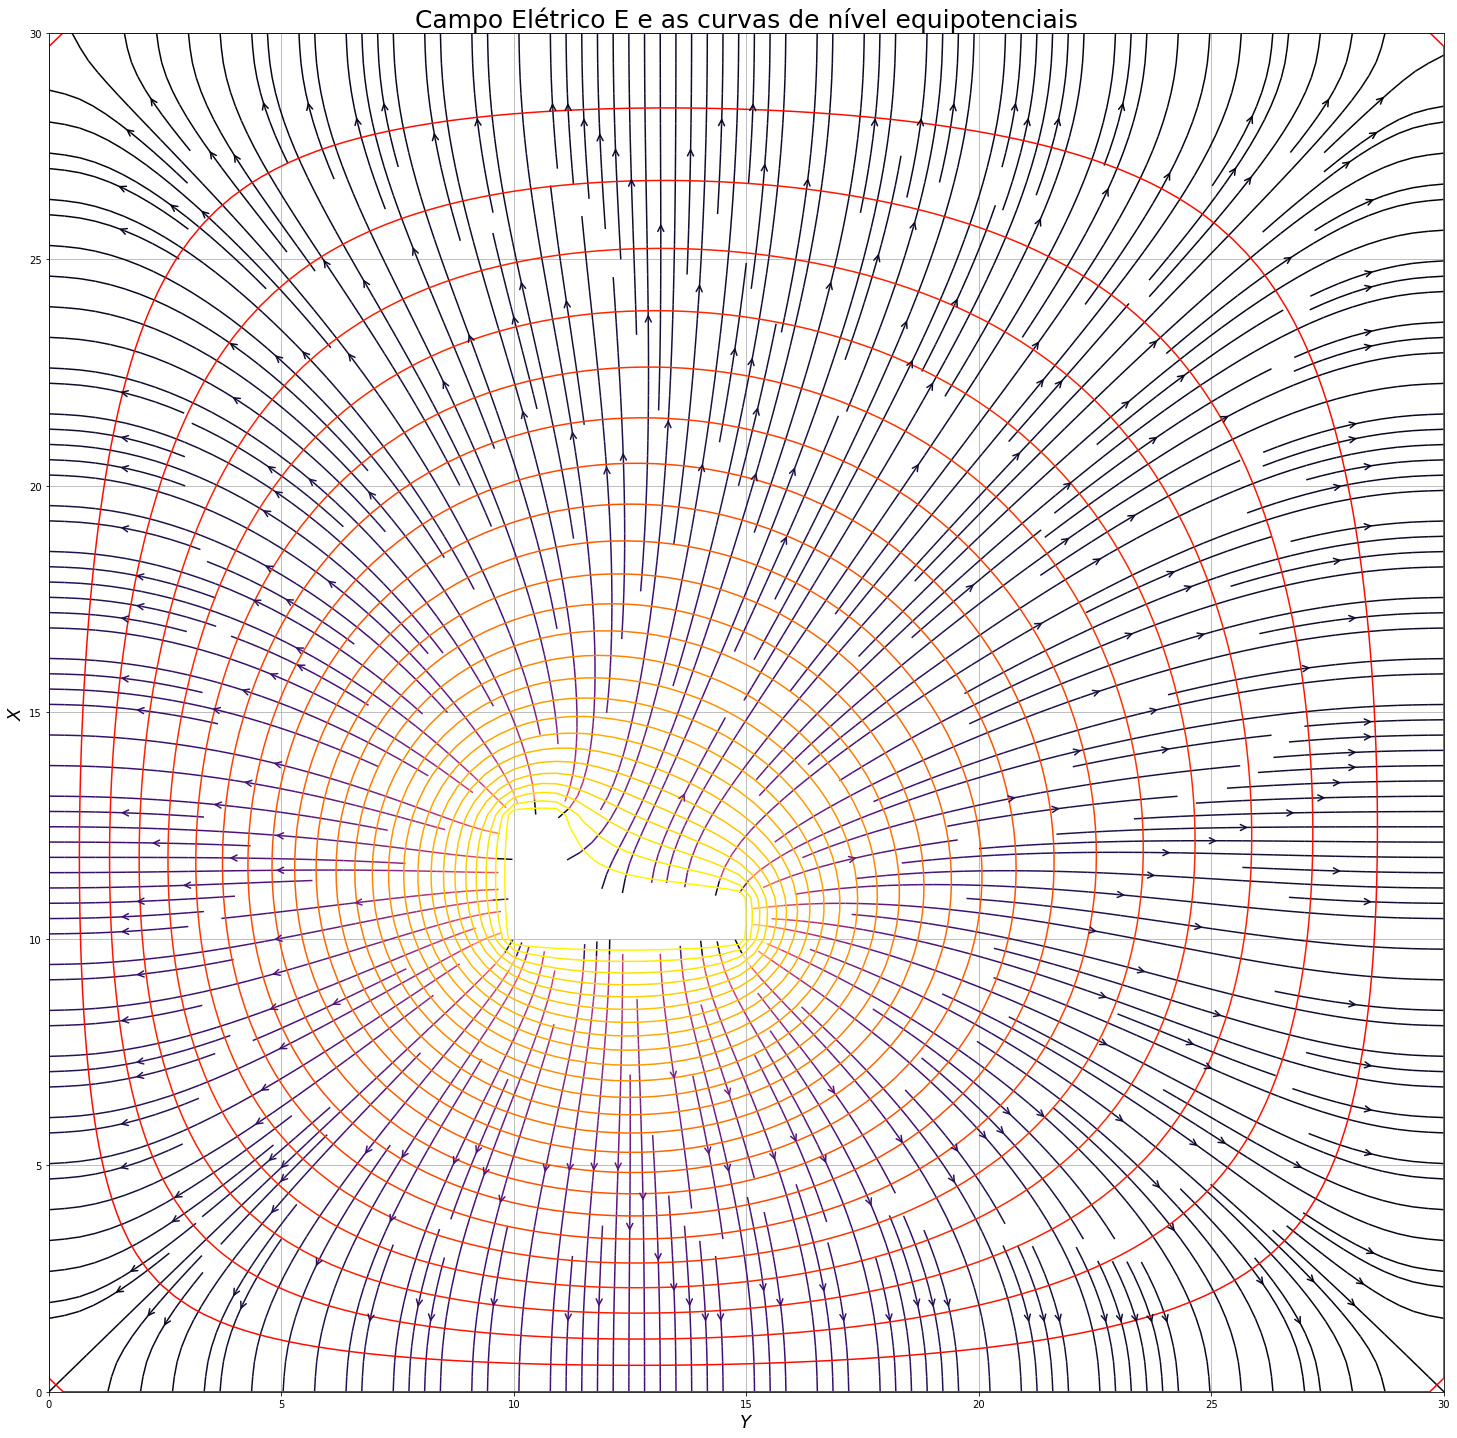

In [ ]:
#O campo é calculado pela variação entre um distancia de 3 pontos, logo delta-l = 2*(30/Nv):
DEL = (30/(Nv-1))

#Funções:
def Ex(x,y):
  #Valores de borda vão dar erro, ou seja 0 e Nv - 1, para 100 é 99
  #if x == 0 or x == Nv-1:
  if Z[x][y] == 10 or Z[x][y] == 0:
     resp = 0
  else: resp = -(Z[x+1][y]-Z[x-1][y])/(2*DEL)
  return resp

def Ey(x,y):
  #Valores de borda vão dar erro
  #if y == 0 or y == Nv-1:
  if Z[x][y] == 10 or Z[x][y] == 0:
     resp = 0
  else: resp = -(Z[x][y+1]-Z[x][y-1])/(2*DEL)
  return resp
print(Ex(23,10))
print("Ex(50,10) = ",Ex(50,10))
print("Ex(10,30)",Ex(10,30))
print(Z[23+1][10]-Z[23-1][10])
print(Z[5][9])
print(-Z[23-1][10])

#Passar por todos os pontos e calcular o valore do campo em cada um deles:
#Def valores pros eixos x e y:

Nv = 100
x = np.linspace(0,30,Nv)
y = np.linspace(0,30,Nv)

#Grade relação de todos os posiveis valores de x e y:
X,Y = np.meshgrid(x,y)

#Matrizes com os valoes do campo:
Cx = np.zeros((Nv,Nv))
Cy = np.zeros((Nv,Nv))
U = np.zeros((Nv,Nv))
#Todos os valors:
xi=0
for i in x:
  yj=0
  for j in y:
    #print("x,j =",i,j)
    #Valor do campo em x, y, com indice xi yj
    Cx[xi][yj] = Ex(xi,yj)
    #print("Cx=",Cx[xi][yj])
    Cy[xi][yj] = Ey(xi,yj)
    #print("Cy =",Cy[xi][yj])
    U[xi][yj] = np.sqrt(pow(Cx[xi][yj],2)+pow(Cy[xi][yj],2))
    yj = yj+1
  xi = xi+1


#Módulo vetorial do campo E:
#U = np.sqrt(pow(a,2)+pow(b,2))

#Plotagem dos valores do campo:
#fig, ax = plt.subplots(figsize=(15, 10))
fig, ax = plt.subplots(figsize=(25, 25))

#Linhas de campo
#plt.streamplot(x,y,Cx,Cy,density=3, linewidth=None,color=U,  cmap='magma', arrowstyle='->', arrowsize=1.5)
plt.streamplot(y,x,Cy,Cx,density=3, linewidth=None,color=U,  cmap='magma', arrowstyle='->', arrowsize=1.5)
#Curvas de nivel:
#CS = ax.contour(X, Y, U,25,cmap='autumn')
#ax.clabel(CS, inline=0.5, fontsize=8)
ax.contour(X, Y, Z,25,cmap='autumn', linewidth=0)

#ax.set_title('Curvas de nÃ­vel')
#Por quiver:
#ax.quiver(x,y,Cx,Cy)

plt.grid()
plt.title('Campo Elétrico E e as curvas de nível equipotenciais',fontsize=25)
ax.set_xlabel('$Y$',fontsize=18)
ax.set_ylabel('$X$',fontsize=18)
plt.show()